In [1]:
from nmmlab.stuart_landau import sl, sl_forced, sl_network, bifurcation_curve
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#PARAMETERS
# single oscillator
omega = 2.0
gamma = 1.0
beta  = 0.0
z0    = 0.3 + 0j
t     = np.linspace(0, 10, 2000)

# damping regime
z0_damp = 0.5 + 0j

# forced oscillator
alpha_forced = -0.3
F0           = 0.5
t_forced     = np.linspace(0, 60, 3000)
z0_forced    = 0 + 0j

# network
N = 3
alphas = np.ones(N) * 0.5
omegas = np.array([2.0, 2.3, 1.7])
gammas = np.ones(N)
betas  = np.zeros(N)
C = np.ones((N, N))
np.fill_diagonal(C, 0)
C /= N
z0_net = np.array([0.3+0j, -0.2+0j, 0.1+0.3j])
t_net  = np.linspace(0, 15, 3000)

# bifurcation diagram
alpha_range = np.linspace(-1.0, 2.0, 600)


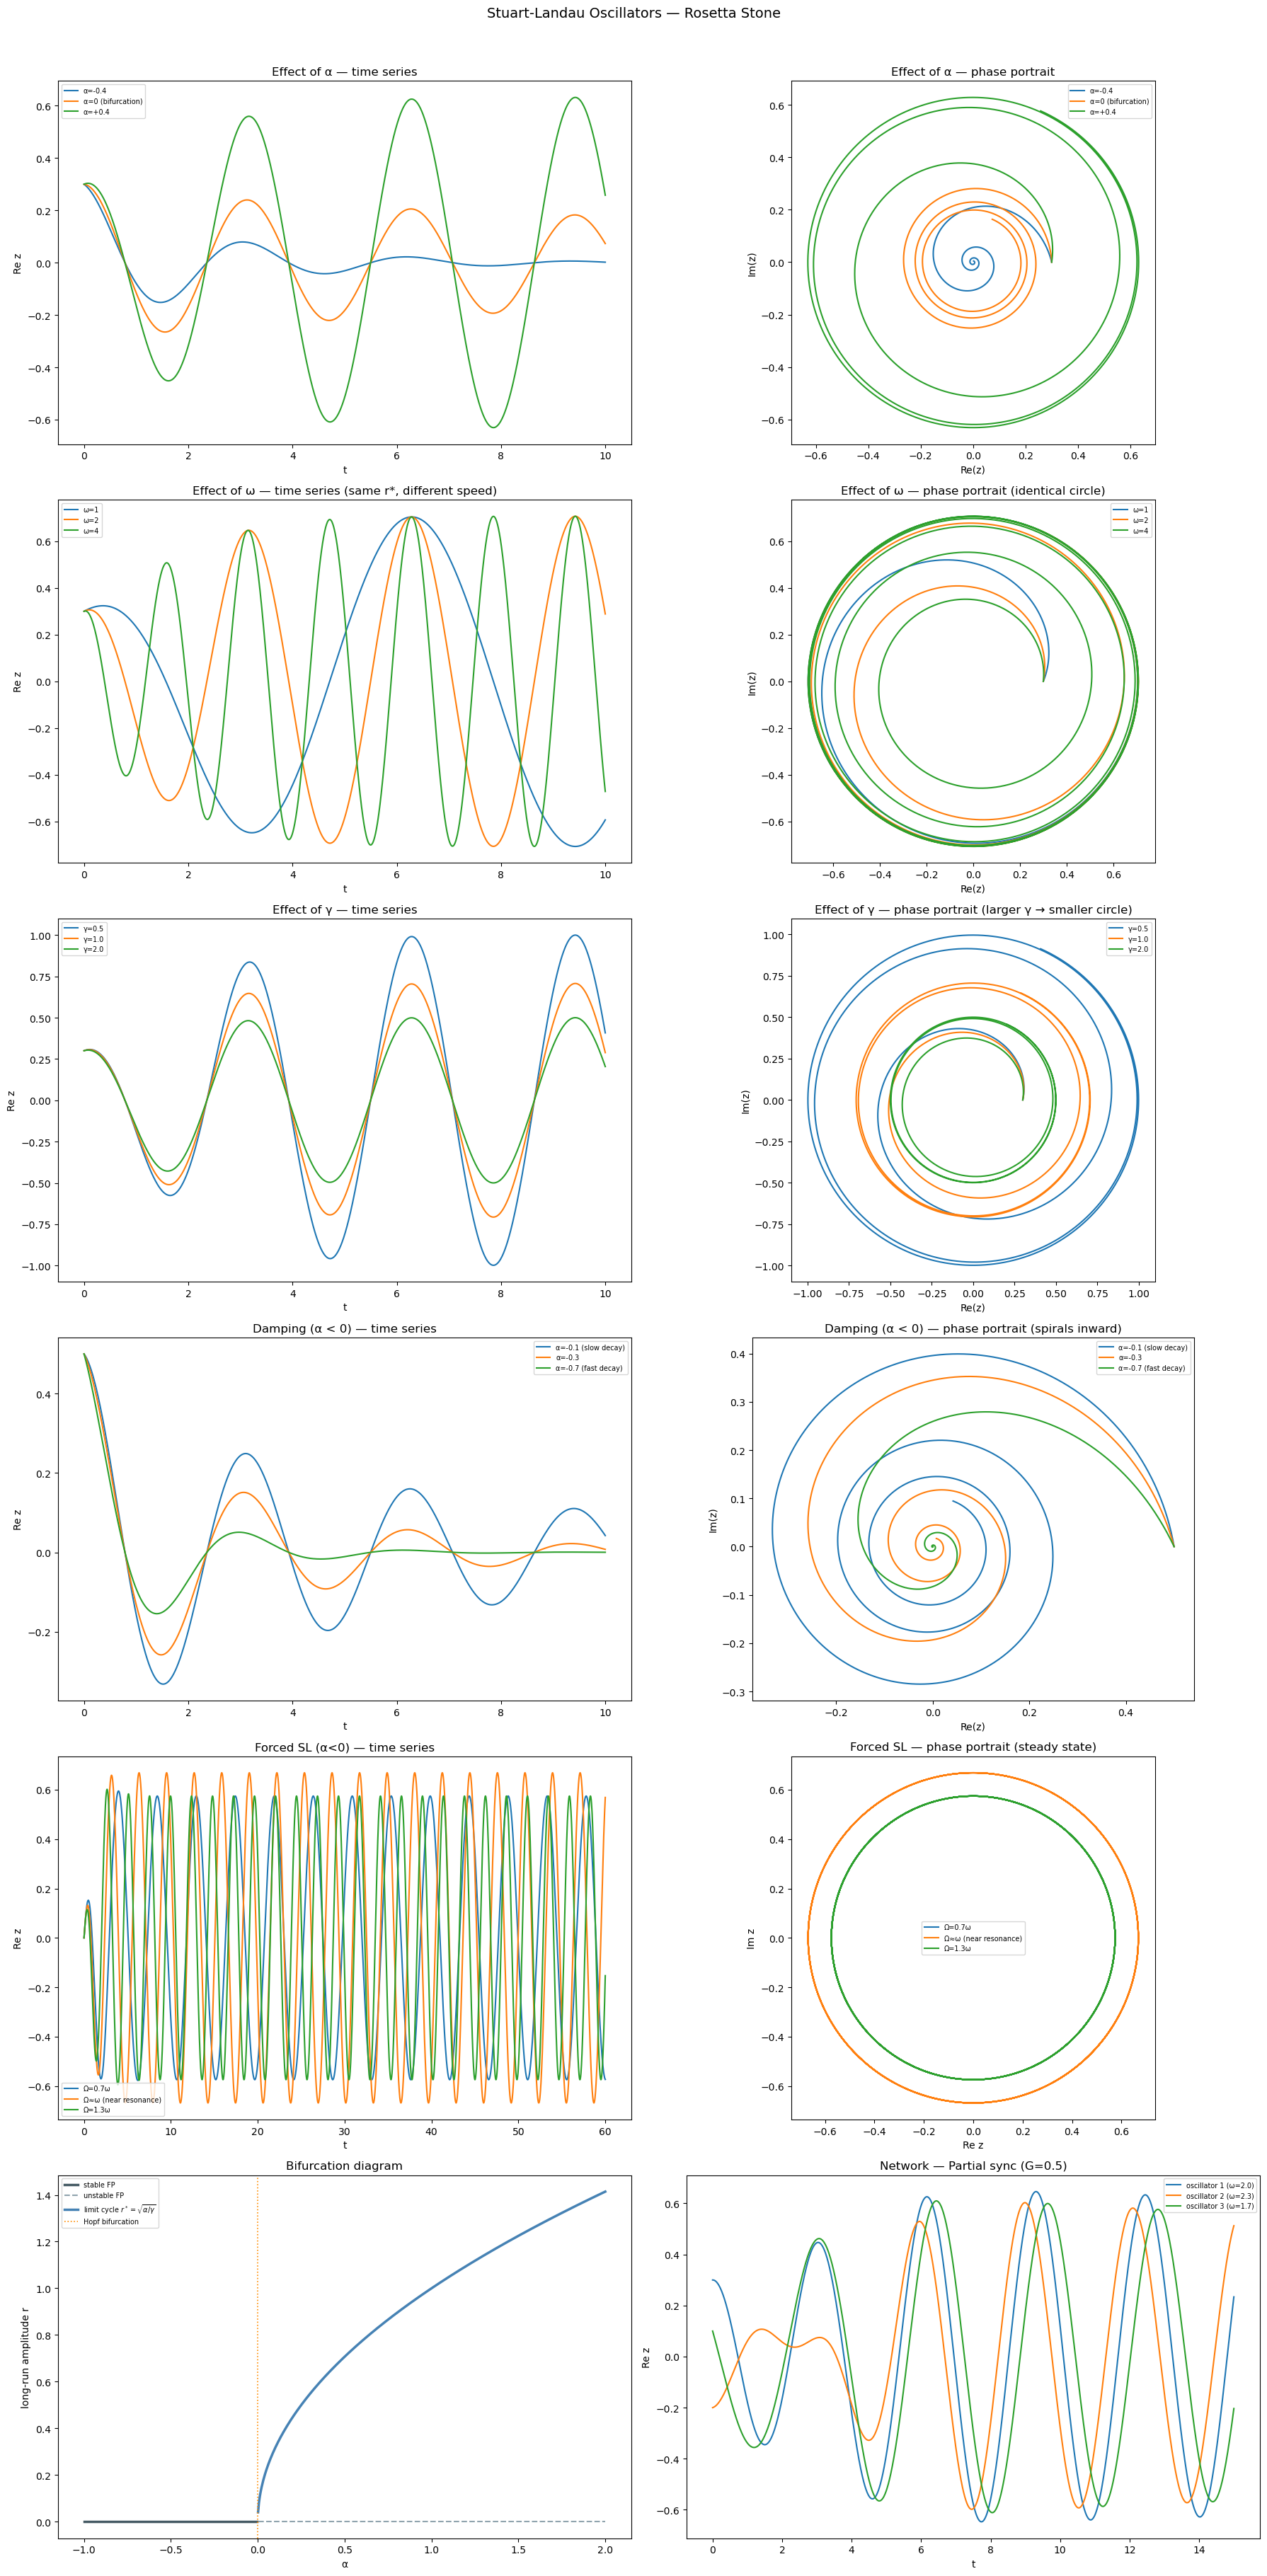

In [3]:
fig = plt.figure(figsize=(18, 36))

# ── Row 1: Effect of α ──
ax1 = fig.add_subplot(6, 2, 1)
ax2 = fig.add_subplot(6, 2, 2)
for alpha_val, label in zip([-0.4, 0.0, 0.4], ['α=-0.4', 'α=0 (bifurcation)', 'α=+0.4']):
    z = sl(alpha_val, omega, gamma, beta, z0, t)
    ax1.plot(t, z.real, label=label)
    ax2.plot(z.real, z.imag, label=label)
ax1.set_title("Effect of α — time series")
ax1.set_xlabel("t"); ax1.set_ylabel("Re z")
ax2.set_title("Effect of α — phase portrait")
ax2.set_xlabel("Re(z)"); ax2.set_ylabel("Im(z)")
ax2.set_aspect("equal")
ax1.legend(fontsize=7); ax2.legend(fontsize=7)

# ── Row 2: Effect of ω ──
ax3 = fig.add_subplot(6, 2, 3)
ax4 = fig.add_subplot(6, 2, 4)
for omega_val, label in zip([1.0, 2.0, 4.0], ['ω=1', 'ω=2', 'ω=4']):
    z = sl(0.5, omega_val, gamma, beta, z0, t)
    ax3.plot(t, z.real, label=label)
    ax4.plot(z.real, z.imag, label=label)
ax3.set_title("Effect of ω — time series (same r*, different speed)")
ax3.set_xlabel("t"); ax3.set_ylabel("Re z")
ax4.set_title("Effect of ω — phase portrait (identical circle)")
ax4.set_xlabel("Re(z)"); ax4.set_ylabel("Im(z)")
ax4.set_aspect("equal")
ax3.legend(fontsize=7); ax4.legend(fontsize=7)

# ── Row 3: Effect of γ ──
ax5 = fig.add_subplot(6, 2, 5)
ax6 = fig.add_subplot(6, 2, 6)
for gamma_val, label in zip([0.5, 1.0, 2.0], ['γ=0.5', 'γ=1.0', 'γ=2.0']):
    z = sl(0.5, omega, gamma_val, beta, z0, t)
    ax5.plot(t, z.real, label=label)
    ax6.plot(z.real, z.imag, label=label)
ax5.set_title("Effect of γ — time series")
ax5.set_xlabel("t"); ax5.set_ylabel("Re z")
ax6.set_title("Effect of γ — phase portrait (larger γ → smaller circle)")
ax6.set_xlabel("Re(z)"); ax6.set_ylabel("Im(z)")
ax6.set_aspect("equal")
ax5.legend(fontsize=7); ax6.legend(fontsize=7)

# ── Row 4: Damping (α < 0) ──
ax7 = fig.add_subplot(6, 2, 7)
ax8 = fig.add_subplot(6, 2, 8)
for alpha_val, label in zip([-0.1, -0.3, -0.7], ['α=-0.1 (slow decay)', 'α=-0.3', 'α=-0.7 (fast decay)']):
    z = sl(alpha_val, omega, gamma, beta, z0_damp, t)
    ax7.plot(t, z.real, label=label)
    ax8.plot(z.real, z.imag, label=label)
ax7.set_title("Damping (α < 0) — time series")
ax7.set_xlabel("t"); ax7.set_ylabel("Re z")
ax8.set_title("Damping (α < 0) — phase portrait (spirals inward)")
ax8.set_xlabel("Re(z)"); ax8.set_ylabel("Im(z)")
ax8.set_aspect("equal")
ax7.legend(fontsize=7); ax8.legend(fontsize=7)

# ── Row 5: Forced SL — time series + phase portrait ──
ax9  = fig.add_subplot(6, 2, 9)
ax10 = fig.add_subplot(6, 2, 10)
drives = [omega * 0.7, omega * 0.99, omega * 1.3]
labels_f = ['Ω=0.7ω', 'Ω≈ω (near resonance)', 'Ω=1.3ω']
for od, lab in zip(drives, labels_f):
    z = sl_forced(alpha_forced, omega, gamma, beta, F0, od, z0_forced, t_forced)
    ax9.plot(t_forced, z.real, label=lab)
ax9.set_title("Forced SL (α<0) — time series")
ax9.set_xlabel("t"); ax9.set_ylabel("Re z")
ax9.legend(fontsize=7)
t_ss = np.linspace(40, 60, 1000)
idx = np.searchsorted(t_forced, 40)
for od, lab in zip(drives, labels_f):
    z = sl_forced(alpha_forced, omega, gamma, beta, F0, od, z0_forced, t_forced)
    ax10.plot(z.real[idx:], z.imag[idx:], label=lab)
ax10.set_title("Forced SL — phase portrait (steady state)")
ax10.set_xlabel("Re z"); ax10.set_ylabel("Im z")
ax10.set_aspect("equal")
ax10.legend(fontsize=7)

# ── Row 6: Bifurcation diagram + Network time series ──
ax11 = fig.add_subplot(6, 2, 11)
r_s, r_u, r_lc = bifurcation_curve(alpha_range, gamma)
ax11.plot(alpha_range, r_s,  color='#455A64', lw=2.5, label='stable FP')
ax11.plot(alpha_range, r_u,  color='#90A4AE', lw=1.5, ls='--', label='unstable FP')
ax11.plot(alpha_range, r_lc, color='steelblue', lw=2.5, label=r'limit cycle $r^*=\sqrt{\alpha/\gamma}$')
ax11.axvline(0, color='darkorange', lw=1.2, ls=':', label='Hopf bifurcation')
ax11.set_title("Bifurcation diagram")
ax11.set_xlabel("α"); ax11.set_ylabel("long-run amplitude r")
ax11.legend(fontsize=7)

ax12 = fig.add_subplot(6, 2, 12)
Z_net = sl_network(alphas, omegas, gammas, betas, C, 0.5, z0_net, t_net)
for i in range(N):
    ax12.plot(t_net, Z_net[:, i].real, label=f"oscillator {i+1} (ω={omegas[i]})")
ax12.set_title("Network — Partial sync (G=0.5)")
ax12.set_xlabel("t"); ax12.set_ylabel("Re z")
ax12.legend(fontsize=7)

plt.suptitle("Stuart-Landau Oscillators — Rosetta Stone", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

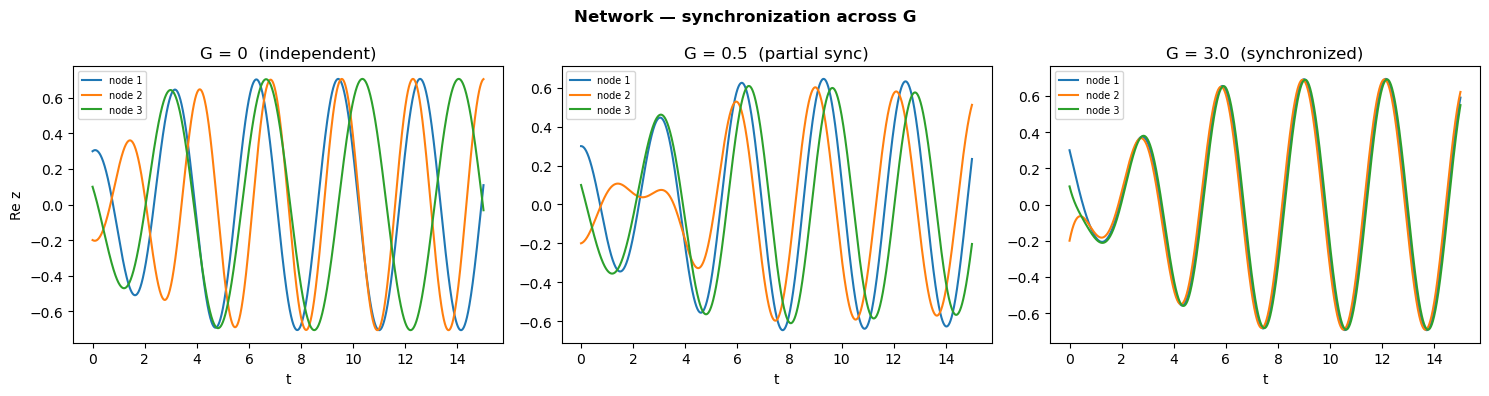

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, G, title in zip(axes, [0.0, 0.5, 3.0],
                        ['G = 0  (independent)', 'G = 0.5  (partial sync)', 'G = 3.0  (synchronized)']):
    Z = sl_network(alphas, omegas, gammas, betas, C, G, z0_net, t_net)
    for i in range(N):
        ax.plot(t_net, Z[:, i].real, label=f'node {i+1}')
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Re z')
plt.suptitle('Network — synchronization across G', fontweight='bold')
plt.tight_layout()
plt.show()